# Cleaned data and features
2026 Joey Manani & Anchorfish Team

`eda_raw.ipynb` looked at the raw Kaggle file to decide **what to clean**. This notebook looks at the data **after** cleaning and feature extraction (the Kaggle rows of `Final Tree/4. Final Data…/features.csv`, made from the cleaned data by the feature extractor and `eda_merged.ipynb` shows the Kaggle and Mendeley combination)

Goals from this EDA:

1. check that cleaning did what it was meant to do
2. check which features carry signal and whether any of them is a shortcut (area under curve (AUC) too high - 'too' confident of a signal)
3. determines reasonable models

The classifier only sees Legitimate and Phishing. Malware and defacement are kept aside for testing later, so we will use those two types only.

Every chart ends in a decision; table at the bottom of this notebook

Every code cell starts with a comment saying what it's based on and what was changed. Full references at the bottom.

In [1]:
# Joey Manani 2026

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

import style

style.use()

############## SEE README ################
FINAL_TREE = Path("datasets/Final Tree")
RAW            = FINAL_TREE / "1 Raw Data - Run These Through Cleaning Scripts" / "malicious_phish.csv"        # raw Kaggle 
KAGGLE_CLEAN   = FINAL_TREE / "2. Cleaned Data - Already Processed With Cleaning Scripts" / "kaggle_clean.csv" # cleaned Kaggle data
FEATURES       = FINAL_TREE / "4. Final Data - Run Through Feature Extractor Script" / "features.csv"          # cleaned data run through the feature extractor
##########################################
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)
SEED = 42  # same random samples every run

SCHEME = r"^[a-zA-Z][a-zA-Z0-9+.-]*://"  # http://, https://

# keep_default_na=False means an empty tld/root_domain (like IP hosts) stay "" instead of NAN
df = pd.read_csv(FEATURES, keep_default_na=False)
df = df[df.url.isin(set(pd.read_csv(KAGGLE_CLEAN, keep_default_na=False).url))]  # cross-ref kaggle rows only - select only kaggle rows from combined features.csv final dataset. Combination analysed in eda_merged
df["type"] = pd.Categorical(df.type, categories=style.TYPE_ORDER) # constrain the CSV types into the expected types from style.py

TEXT_COLUMNS = ["url", "type", "tld", "root_domain"]  # not model inputs
FEATURE_COLUMNS = [c for c in df.columns if c not in TEXT_COLUMNS] # everything else.

# what the classifier will see
legit_and_phishing = df[df.type.isin(["Legitimate", "Phishing"])].copy() # clone out Legitimate and Phishing into a new dataframe
legit_and_phishing["type"] = legit_and_phishing.type.cat.remove_unused_categories() # remove empty categories (column exists, no data = strip)
is_phishing = legit_and_phishing.type.eq("Phishing") # boolean series indicating which rows are phishing - for later

print(f"{len(df)} rows, {len(FEATURE_COLUMNS)} features, {len(legit_and_phishing)} of them legit or phishing")
# therefore len(df) - len(legit_and_phishing) rows are not legitimate or phishing = malware, defacement here.

632717 rows, 54 features, 513849 of them legit or phishing


## 0. Quick health check
The Week 6 "five commands". With 54 feature columns, `describe()` is cut down to just min and max so it stays readable.

In [2]:
# Based on: the Week 6 seminar's "five commands", and pandas' "10 minutes to pandas" guide (Viewing data: head, dtypes,
# describe; Missing data: isna/isnull). describe() cut to min/max is the seminar's tip for wide tables
print(df.head(3), "\n")
print(df.dtypes.value_counts(), "\n")  # 58 columns, so count the types instead of listing them
print("missing values:", df.isnull().sum().sum())
print("exact duplicate rows:", df.duplicated().sum())
df[FEATURE_COLUMNS].describe().loc[["min", "max"]].T

                                                 url        type  path_level  \
0                mp3raid.com/music/krizz_kaliko.html  Legitimate           2   
1                    bopsecrets.org/rexroth/cr/1.htm  Legitimate           3   
2  buzzfil.net/m/show-art/ils-etaient-loin-de-s-i...  Legitimate           3   

   path_length  double_slash_path  query_length  num_query_components  \
0           24                  0             0                     0   
1           17                  0             0                     0   
2          100                  0             0                     0   

    entropy  host_entropy  path_entropy  ...  is_ip_host  \
0  4.165894      3.277613      3.855389  ...       False   
1  3.745465      3.235926      3.292770  ...       False   
2  4.240544      3.277613      4.059429  ...       False   

   has_non_standard_port  https_in_hostname  domain_has_punycode  host_length  \
0                  False              False                False

,min,max
path_level,0.000000,38.000000
path_length,0.000000,2156.000000
double_slash_path,0.000000,1.000000
query_length,0.000000,2005.000000
num_query_components,0.000000,51.000000
entropy,2.069616,6.012565
host_entropy,0.721928,5.041506
path_entropy,0.000000,5.943880
query_entropy,0.000000,5.979687
subdomain_count,0.000000,33.000000


## 1. Class balance after cleaning
How many URLs of each type are left. This decides how to score the models: if one class is much bigger, accuracy is misleading.

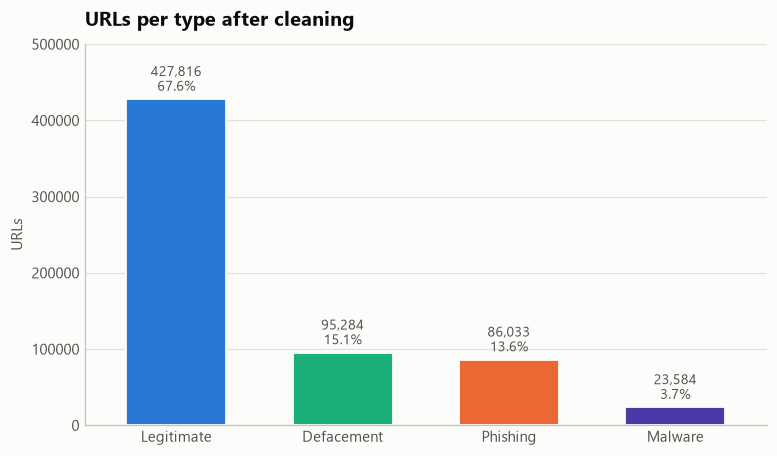

Legit vs phishing only: 83.3% / 16.7%


In [3]:
# Based on: matplotlib's "Bar chart with labels" example (ax.bar_label with custom labels= and padding=)
# Changed: each label shows the count and the % together


# swap these around if we want to focus just on legit and phishing comparison
counts = df.type.value_counts()
# counts = legit_and_phishing.type.value_counts()

share = counts / counts.sum() * 100
ax = counts.plot.bar(rot=0, xlabel="", width=0.6, color=style.colours(counts.index), ylabel="URLs", title="URLs per type after cleaning")

ax.grid(False, axis="x")
ax.bar_label(ax.containers[0], labels=[f"{number:,}\n{percentage:.1f}%" for number, percentage in zip(counts, share)],
             padding=3, color=style.INK_SOFT, fontsize=9)

# make y axis 0 - 500000 to ensure title is not clipped
ax.set_ylim(0, 500000)

style.save(ax.figure, FIGURES / "features_class_balance.png")
plt.show()

print(f"Legit vs phishing only: {np.logical_not(is_phishing).mean():.1%} / {is_phishing.mean():.1%}")

So, because of class imbalance, we need to be careful when interpreting the results. If this is not accounted for, a model that always guesses "Legitimate" 83.3% of the time for any *random* URL from the set will be treated as correct since phishing only makes up 16.7% of the data. Precision, recall, F1 and PR-AUC will be very useful metrics for evaluation.

## 2. Did the cleaning work?
This compares the hypothesis from section 7 from `eda_raw` before and after cleaning, for legit and phishing URLs. Pale bars show the raw file as labelled. Solid bars show the cleaned data, which also fixes the two swapped blocks

Then we look at URL length again, since section 7 showed that "phishing URLs are shorter" was mostly caused by the swapped blocks.

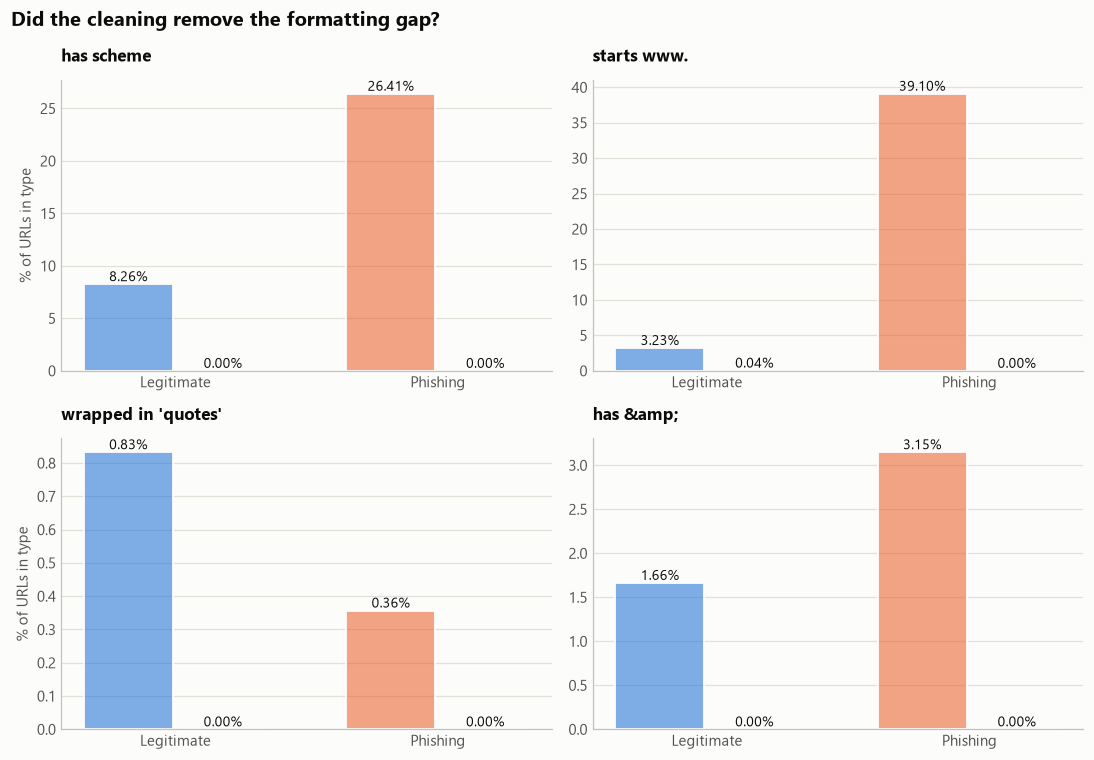

has scheme  starts www.  wrapped in 'quotes'  has &amp;
        type                                                               
raw     Legitimate        8.26         3.23                 0.83       1.66
        Phishing         26.41        39.10                 0.36       3.15
cleaned Legitimate        0.00         0.04                 0.00       0.00
        Phishing          0.00         0.00                 0.00       0.00

In [4]:
# Based on: matplotlib's "Grouped bar chart with labels" example (two bars side by side per group, labelled with bar_label)
# Changed: the example now uses ax.grouped_bar(), which colours bars by dataset (raw vs cleaned). Here the bars are
# at x - 0.18 and x + 0.18 and colours show URL type, with pale = raw and solid = cleaned
from matplotlib.colors import to_rgba

raw = pd.read_csv(RAW)
raw["type"] = raw.type.map(style.KAGGLE_NAMES)

LABELS = ["Legitimate", "Phishing"] # select just these two


def format(urls):
    """Formatting quirks the cleaning should remove (same rules as eda_raw states)"""
    bare = urls.str.replace(SCHEME, "", regex=True)
    return pd.DataFrame({
        "has scheme": urls.str.match(SCHEME),
        "starts www.": bare.str.match(r"(?i)www\d*\."),
        "wrapped in 'quotes'": urls.str.match(r"^'.*'$"),
        "has &amp;": urls.str.contains("&amp;", regex=False),
    })

# want percentages for both the raw and clean data here
raw_pct   = format(raw.url).groupby(raw.type).mean().loc[LABELS] * 100
clean_pct = format(df.url) .groupby(df.type) .mean().loc[LABELS] * 100

pos_offset_x = np.arange(len(LABELS))
colours = [style.TYPE_COLOURS[t] for t in LABELS]
pale = [to_rgba(c, 0.6) for c in colours]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, flag in zip(axes.flat, raw_pct.columns):
    raw_bars   = ax.bar(pos_offset_x - 0.18, raw_pct[flag],   0.34, color=pale,    label="raw")     # left
    clean_bars = ax.bar(pos_offset_x + 0.18, clean_pct[flag], 0.34, color=colours, label="cleaned") # right (solid colour, cant even be seen)
    ax.bar_label(raw_bars, fmt="%.2f%%", fontsize=9)  #  two decimal places to reveal that www actually has 0.04
    ax.bar_label(clean_bars, fmt="%.2f%%", fontsize=9)
    ax.set_xticks(pos_offset_x, LABELS)
    ax.set_title(flag, fontsize=11)

for ax in axes[:, 0]: # left side axes only
    ax.set_ylabel("% of URLs in type")

fig.suptitle("Did the cleaning remove the formatting gap?", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
style.save(fig, FIGURES / "features_cleaning_before_after.png")
plt.show()

pd.concat({"raw": raw_pct, "cleaned": clean_pct}).round(2)

Okay... So cleaning worked, it removed the formatting gap between legitimate and phishing URLs.
Something really interesting to see is that there is still 0.04% of legitimate URLs that still start with "www."
Upon analysing the data, this is actually domains like "www.gov.uk" or "www.nhs.uk". This is a quirk of the way the feature extraction works since technically .gov.uk is the TLD, making "www" the technical root domain. Feature extraction only drops www if its a subdomain, not a root domain.

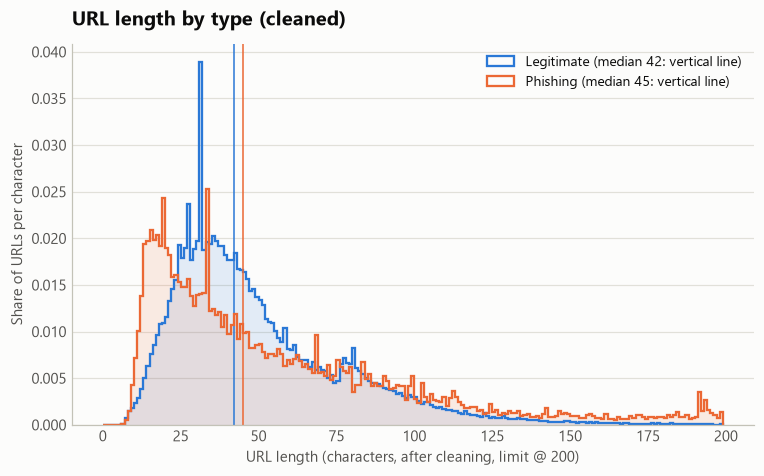

,raw median (as labelled),cleaned median
type,,
Defacement,81.0,71.0
Legitimate,46.0,42.0
Malware,49.0,30.0
Phishing,35.0,45.0


In [5]:
# Based on: matplotlib's "Demo of the histogram function's different histtype settings" example (density=True,
# histtype="stepfilled" and "step"). Changed: both drawn on top of each other (pale fill + outline) for two types, plus a median line
clean_length = legit_and_phishing.url.str.len() # Calculate the length of each cleaned URL
BINS = range(0, 200, 1)

fig, ax = plt.subplots()
for url_type in ["Legitimate", "Phishing"]:
    colour = style.TYPE_COLOURS[url_type]
    lengths = clean_length[legit_and_phishing.type == url_type]

    ax.hist(lengths, bins=BINS, density=True, histtype="stepfilled", color=colour, alpha=0.12, edgecolor="none")
    median = lengths.median()
    ax.hist(lengths, bins=BINS, density=True, histtype="step", color=colour, linewidth=1.5,
            label=f"{url_type} (median {median:.0f}: vertical line)")
    ax.axvline(median, color=colour, linewidth=1)

ax.set_xlabel("URL length (characters, after cleaning, limit @ 200)")
ax.set_ylabel("Share of URLs per character")
ax.set_title("URL length by type (cleaned)")
ax.legend()
style.save(fig, FIGURES / "features_length_cleaned.png")
plt.show()

pd.DataFrame({
    "raw median (as labelled)": raw.url.str.len().groupby(raw.type).median(),
    "cleaned median": df.url.str.len().groupby(df.type).median(),
})

Why does the raw EDA (section 7d) show Legitimate = 42 and Phishing = 47, while the chart above shows 42 and 45? The raw EDA only stripped the scheme and flipped the swapped blocks back. The cleaning script does two more things, and both shorten phishing more than legit:

1. canonical_url also strips www., removes the 'quotes', undoes the \% escapes and turns &amp; back into &. After the flip, about 21% of phishing URLs started with www. against 7% of legit, so phishing loses more characters 47 to 46 (no rows removed yet)
2. Duplicates are removed. Most of the removed phishing copies were longer than the median, so the median drops more 46 to 45.

Legitimate stays at 42 through both steps. Phishing is still a little longer than legit after cleaning, just by less than what raw EDA thought

## 3. Top TLDs by type
Moved here from `eda_raw`, because the `tld` column only exists after feature extraction.

Shown as % of each type. URLs without TLD (IP hosts) are left out, which is about half of the malware ones

The first chart is the top 5 TLDs per type (deduplicated), side by side. The second chart is each type's own top 5 (not deduped)

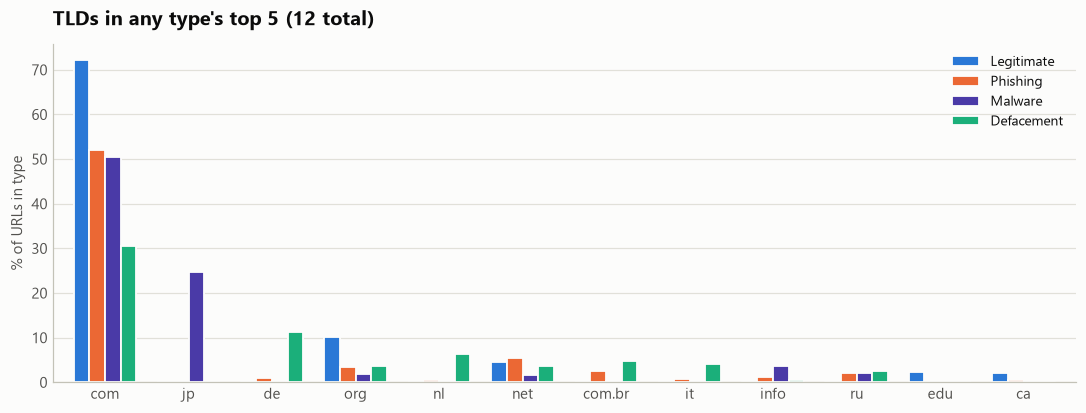

type,Legitimate,Phishing,Malware,Defacement
tld,,,,
com,72.28,52.08,50.58,30.58
jp,0.18,0.12,24.60,0.04
de,0.40,1.06,0.38,11.30
org,10.24,3.48,1.87,3.74
nl,0.13,0.50,0.26,6.29
net,4.53,5.47,1.73,3.58
com.br,0.16,2.62,0.39,4.74
it,0.12,0.84,0.17,4.21
info,0.30,1.25,3.56,0.55


In [6]:
# Based on: the pandas.crosstab docs (normalize="columns" turns counts into % within each type) and pandas' DataFrame.plot.bar
has_tld = df[df.tld != ""]  # IP hosts have no TLD

# % of each type's URLs per TLD
tld_share = pd.crosstab(has_tld.tld, has_tld.type, normalize="columns") * 100

# TLDs in the top 5 of at least one type
top = tld_share[(tld_share.rank(ascending=False, method="first") <= 5).any(axis=1)]
top = top.loc[top.max(axis=1).sort_values(ascending=False).index]  # biggest bars first

ax = top.plot.bar(
    figsize=(12, 4), rot=0, width=0.75, xlabel="", ylabel="% of URLs in type", color=style.colours(top.columns),
    title=f"TLDs in any type's top 5 ({len(top)} total)",
)
ax.grid(False, axis="x")
ax.legend()
style.save(ax.figure, FIGURES / "features_tld_top5_by_type.png")
plt.show()

top.round(2)

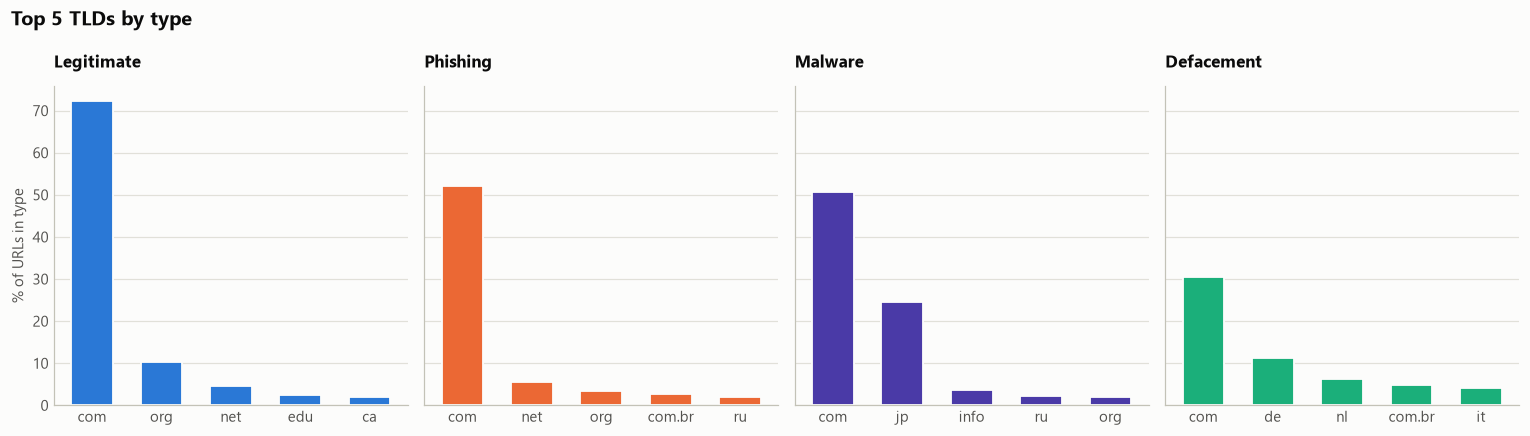

,Legitimate,Phishing,Malware,Defacement
rank,,,,
1,com (72.28%),com (52.08%),com (50.58%),com (30.58%)
2,org (10.24%),net (5.47%),jp (24.60%),de (11.30%)
3,net (4.53%),org (3.48%),info (3.56%),nl (6.29%)
4,edu (2.35%),com.br (2.62%),ru (2.10%),com.br (4.74%)
5,ca (2.02%),ru (2.06%),org (1.87%),it (4.21%)


In [7]:
# Same sources as the cell above, drawn as one small chart per type (plt.subplots with sharey=True so the bars compare on same scale)
fig, axes = plt.subplots(1, tld_share.shape[1], figsize=(14, 4), sharey=True)

for ax, t in zip(axes, tld_share.columns):
    tld_share[t].nlargest(5).plot.bar(ax=ax, rot=0, xlabel="", width=0.6, color=style.TYPE_COLOURS[t])
    ax.set_title(t, fontsize=11)
    ax.grid(False, axis="x")
axes[0].set_ylabel("% of URLs in type")
fig.suptitle("Top 5 TLDs by type", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
style.save(fig, FIGURES / "features_tld_top5_each_type.png")
plt.show()

# sum to percentages
pd.DataFrame(
    {t: [f"{tld} ({pctage:.2f}%)" for tld, pctage in tld_share[t].nlargest(5).items()] for t in tld_share.columns},
    index=range(1, 6),
).rename_axis("rank")

`com` is number 1 for every type, but it is 72% of legit and only 31% of defacement.

Defacement is full of country TLDs: `de` 11.3%, `nl` 6.3%, `com.br` 4.7% and `it` 4.2%, and each of those is < 0.5% of legit. Malware has `jp` at 24.6% when it is 0.18% of legit.

A gap that big does not pass the reality test. A quarter of all malware is not `.jp`. Nearly all of the `jp` malware is one single host (`mitsui-jyuku.mixh.jp`), so the model would really be learning that one site. The country TLDs in defacement are probably the same case as it says where the list was collected from more than which TLDs are dangerous for defacement.

Again, we are only focussing on Legitimate and Phishing here though, so actually certain trends can be seen such as `.edu` is probably going to be treated as Legitimate due to its abundance in legitimate domains compared to phishing.

After flipping the mislabelling (see `eda_raw` section 7): `.edu` is 2.35% of legit and 0.02% of phishing, which is what I'd expect. `com` is 72% of legit vs 52% of phishing.

## 4. Which features are strongest?
[//]: <> (This was so interesting to learn and study - Joey)

Let's evaluate the **AUC** of each feature.

This proves the feature differentiates the two types. Let me explain:

- 0.5 = equivalent chance.
- 1.0 (or 0.0) = separates the two types entirely
- "Strength" is both directions together since an AUC of 0.3 is as strong as 0.7, it just means the feature is **lower** in the other type

Anything above about 0.8 would be suspicious and go through the three tests I wrote at the start of `eda_raw` (a likely shortcut like `has_www` was).

Week 6: keep features above 0.2 and say why you dropped the rest. It's in the table as `corr with label`.

Constant (drop before training - useless): []
|correlation| > 0.2 (cutoff): ['host_length', 'num_sensitive_words', 'host_entropy', 'dot_count', 'longest_word_length', 'tld_is_common', 'path_entropy', 'avg_word_length', 'subdomain_length', 'subdomain_digit_ratio', 'subdomain_max_label_length', 'subdomain_count', 'subdomain_hyphen_count', 'subdomain_has_embedded_tld']


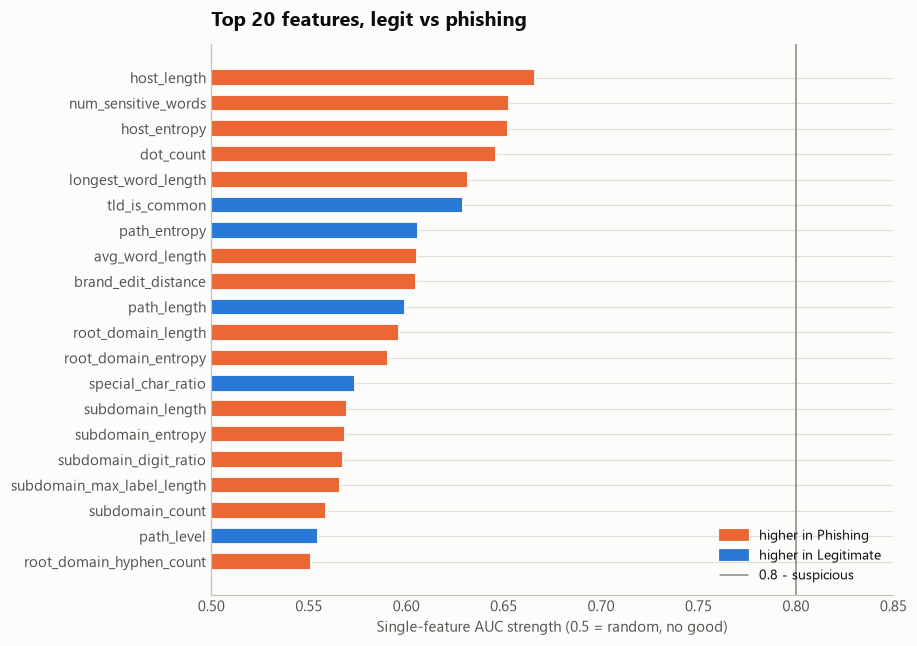

,strength,higher in,corr with label
host_length,0.666,Phishing,0.288
num_sensitive_words,0.653,Phishing,0.438
host_entropy,0.652,Phishing,0.232
dot_count,0.646,Phishing,0.295
longest_word_length,0.632,Phishing,0.315
tld_is_common,0.629,Legitimate,-0.255
path_entropy,0.606,Legitimate,-0.206
avg_word_length,0.605,Phishing,0.252
brand_edit_distance,0.605,Phishing,0.153
path_length,0.599,Legitimate,-0.069


In [8]:
# Computed with scikit-learn's roc_auc_score, using each feature's own values as the score
# Correlation with the label: the Week 6 seminar's 0.2 cutoff, using pandas DataFrame.corrwith
# Chart: matplotlib's "Horizontal bar chart" example (ax.barh)
# Drop features that are the same value for every row (useless)
usable   = [feat for feat in FEATURE_COLUMNS if legit_and_phishing[feat].nunique() > 1] # if each feature has more than ONE differing value
constant = [feat for feat in FEATURE_COLUMNS if feat not in usable] # if the feature is SAME on every URL
values   = legit_and_phishing[usable].astype(float) # converts the value of every single feature to a float

# evaluate each feature on its own
auc = pd.Series({feat: roc_auc_score(is_phishing, values[feat]) for feat in usable})

signal = pd.DataFrame({
    "strength": np.maximum(auc, 1 - auc), # closest to 0 or 1; both directions are equally informative
    "higher in": np.where(auc >= 0.5, "Phishing", "Legitimate"),
    "corr with label": values.corrwith(is_phishing.astype(float)), # check correlation with phishing 
}).sort_values("strength", ascending=False)

# Week 6: a feature counts as correlated with the label if |correlation| > 0.2.
# .abs() so negative correlations (higher in legit) count too.
correlation_strong = signal.index[signal["corr with label"].abs() > 0.2].tolist()


print("Constant (drop before training - useless):", constant)
print("|correlation| > 0.2 (cutoff):", correlation_strong) # just 14 of them have strong enough correlations to the type



# Plot the top 20 AUC, strongest at the top
top20 = signal.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(top20.index, top20.strength, height=0.65, color=style.colours(top20["higher in"]))

# threshold at 0.8 for an oddly suspiciously high AUC
ax.axvline(0.8, color=style.MUTED, linewidth=1, label="0.8 - suspicious")
ax.set_xlim(0.5, 0.85) # want to see threshold
ax.set_xlabel("Single-feature AUC strength (0.5 = random, no good)")
ax.set_title("Top 20 features, legit vs phishing")

phishing_patch = mpl.patches.Patch(color=style.TYPE_COLOURS["Phishing"],   label="higher in Phishing")
legit_patch =    mpl.patches.Patch(color=style.TYPE_COLOURS["Legitimate"], label="higher in Legitimate")
cutoff_line = ax.lines[0]   # the 0.8 line drawn earlier

ax.legend(handles=[phishing_patch, legit_patch, cutoff_line], loc="lower right")
style.save(fig, FIGURES / "features_single_auc.png")
plt.show()

signal.round(3)

Very very good information.

- The strongest feature is host_length at 0.67, and nothings close to 0.8 therefore no feature shortcuts to the answer by itself
- No feature is constant any more. root_domain_has_punycode used to be the same in every row, but after the extractor's punycode bug fix, 115 Kaggle URLs have punycode. It is a near-duplicate (high correlation) with domain_has_punycode now
- Only fourteen features pass the 0.2 correlation cutoff, but fundamentally this test above is testing viability of a LINEAR relationship between features and the target variable. A NON-LINEAR model can combine features to improve correlation, therefore the rest of the features are not just removed from analysis. This suggests that a linear model *can* potentially do okay with just host_length and a few more of the key features, but still a non-linear model like a tree should do better since it can combine these signals

## 5. Visualise eight strongest features
Box plots of the eight strongest features from section 4 that are counts or lengths (a yes/no feature like `tld_is_common` only has two values, so a box plot is meaningless). Whiskers are 5% and 95% with outliers off for clarity

Careful when reading `url_length` in `features.csv`: the extractor adds `http://` to every cleaned URL before measuring, so `url_length` is always **the URL's real length + 7**. That's why its medians (49 / 52) are 7 higher than the histogram in section 2 (42 / 45).

It doesn't matter for training (every row shifts by the same amount, deterministically), but it does mean `url_length == 31` in the CSV is a 24 character URL.

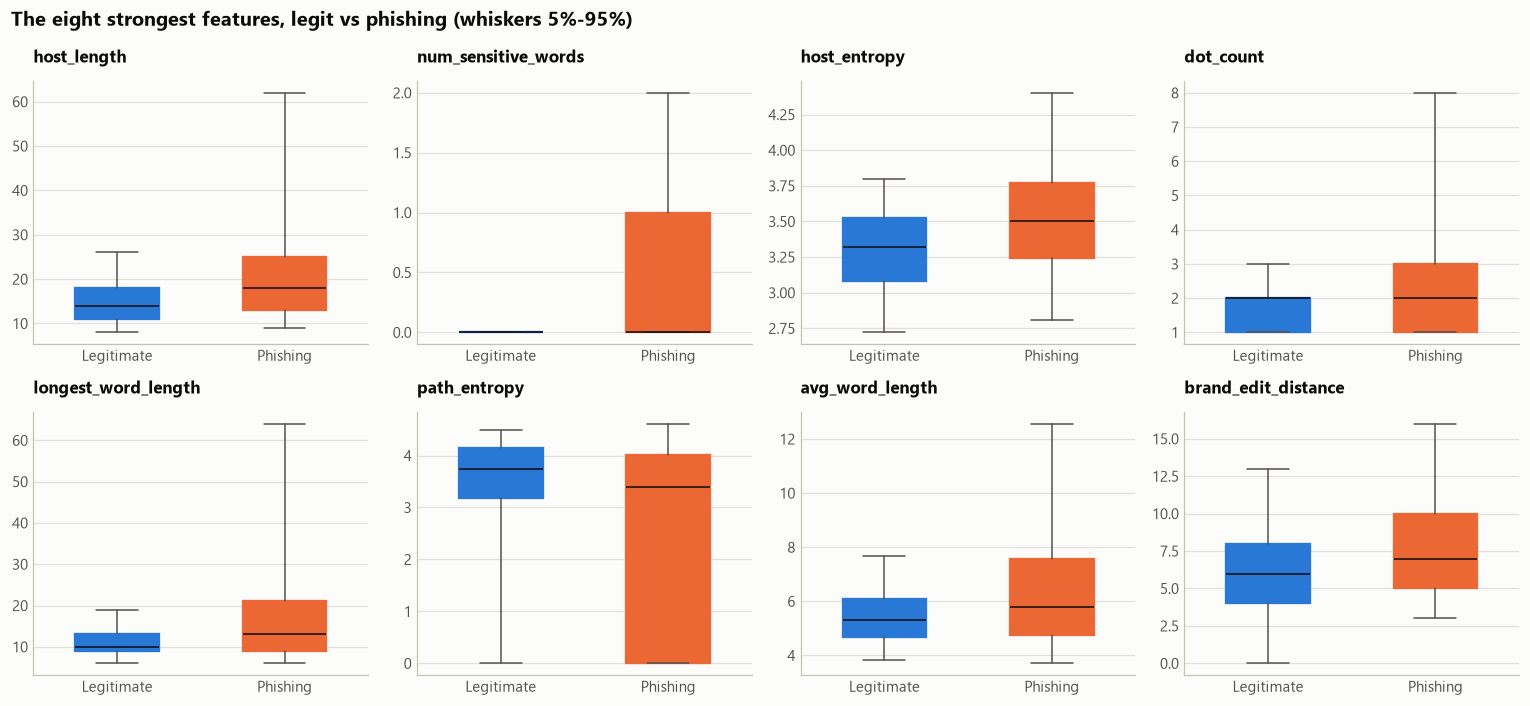

In [9]:
# Based on: matplotlib's "Box plots with custom fill colors" example (patch_artist=True, then colour each box)
# Changed: whis=(5, 95) puts the whiskers at the 5th and 95th percentiles (an option in the Axes.boxplot docs), fliers hidden
# this therefore means that tld_is_common is dropped because its a true/false
top8 = [c for c in signal.index if values[c].nunique() > 2][:8]
fig, axes = plt.subplots(2, 4, figsize=(14, 6.5))
for ax, feature in zip(axes.flat, top8):
    boxes = ax.boxplot(
        [values.loc[np.logical_not(is_phishing), feature], values.loc[is_phishing, feature]],
        tick_labels=["Legitimate", "Phishing"],
        whis=(5, 95),
        showfliers=False,
        widths=0.5,

        patch_artist=True, # change colour
        whiskerprops={"color": style.INK_SOFT},
        capprops={"color": style.INK_SOFT},
    )
    boxes["boxes"][0].set(facecolor=style.TYPE_COLOURS["Legitimate"], edgecolor=style.TYPE_COLOURS["Legitimate"], linewidth=1.5)
    boxes["boxes"][1].set(facecolor=style.TYPE_COLOURS["Phishing"], edgecolor=style.TYPE_COLOURS["Phishing"], linewidth=1.5)
    ax.set_title(feature, fontsize=11)
fig.suptitle("The eight strongest features, legit vs phishing (whiskers 5%-95%)", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
style.save(fig, FIGURES / "features_top8_boxplots.png")
plt.show()

Anything more than 1.5 x IQR below the first quartile or above the third is an outlier (lower fence; upper fence). Counted here for the same eight features:

In [10]:
# Based on: the 1.5 x IQR "lower/upper fence" rule
# Week 4 
q1 = values[top8].quantile(0.25)
q3 = values[top8].quantile(0.75)
iqr = q3 - q1
outside = (values[top8] < q1 - 1.5 * iqr) | (values[top8] > q3 + 1.5 * iqr)
pd.DataFrame({"outliers (1.5 x IQR)": outside.sum(), "% of rows": outside.mean() * 100}).round(1)

,outliers (1.5 x IQR),% of rows
host_length,18516,3.6
num_sensitive_words,31467,6.1
host_entropy,10205,2.0
dot_count,30044,5.8
longest_word_length,33145,6.5
path_entropy,76192,14.8
avg_word_length,24831,4.8
brand_edit_distance,16767,3.3


On half a million URLs the fence rule flags thousands of URLs per feature. That's why the box plots above use 5% and 95% whiskers instead of the 1.5 x IQR standard... There's a lot of variation in the data, and the standard IQR rule is too sensitive to outliers in this case.

**Skewed features and the log transform (Week 4).** A few huge values can dominate distance-based and linear models, though not tree models. Using `log1p` (log(1 + x)), it squashes large values and unlike log, handles 0. We need to handle 0 because yes/no flags, since logging a 1/0 column changes nothing

In [11]:
# Based on: the Week 4 lecture's transforms table (log for skewed data, but log can't take 0), numpy.log1p and pandas skew().
numeric = [col for col in usable if values[col].nunique() > 2]  # counts and lengths, skip boolean values
most_skewed = values[numeric].skew().sort_values(ascending=False).head(8).index
pd.DataFrame({
    "skew": values[most_skewed].skew(),
    "skew after log1p": np.log1p(values[most_skewed]).skew(),
}).round(1)

,skew,skew after log1p
at_count,43.0,22.0
hash_count,39.2,34.4
percent_count,15.9,7.2
subdomain_hyphen_count,13.6,7.9
ampersand_count,12.2,5.0
query_length,10.5,2.3
subdomain_length,10.0,1.7
longest_word_length,9.8,1.8


To clarify, values above 1 are typically considered very skewed. percent_count drops from 15.9 to 7.2 so still a major improvement. The at_count and hash_count feature however don't change as much as that's because they're literally just rare. Applying a log transform to these features doesn't help against something that's just rare to see.

## 6. Which features say the same thing?
Spearman correlation (ranking-based) between every pair of usable features

Spearman correlation flattens out the individual values and only cares about the rank order within the feature. All we want to do is see if the feature correlates to another

Features are ordered so that correlated ones sit next to each other, which makes blocks of near-duplicates visible.

The table lists every pair above 0.9. Near-duplicates make logistic regression weights unreliable. Tree models are immune.

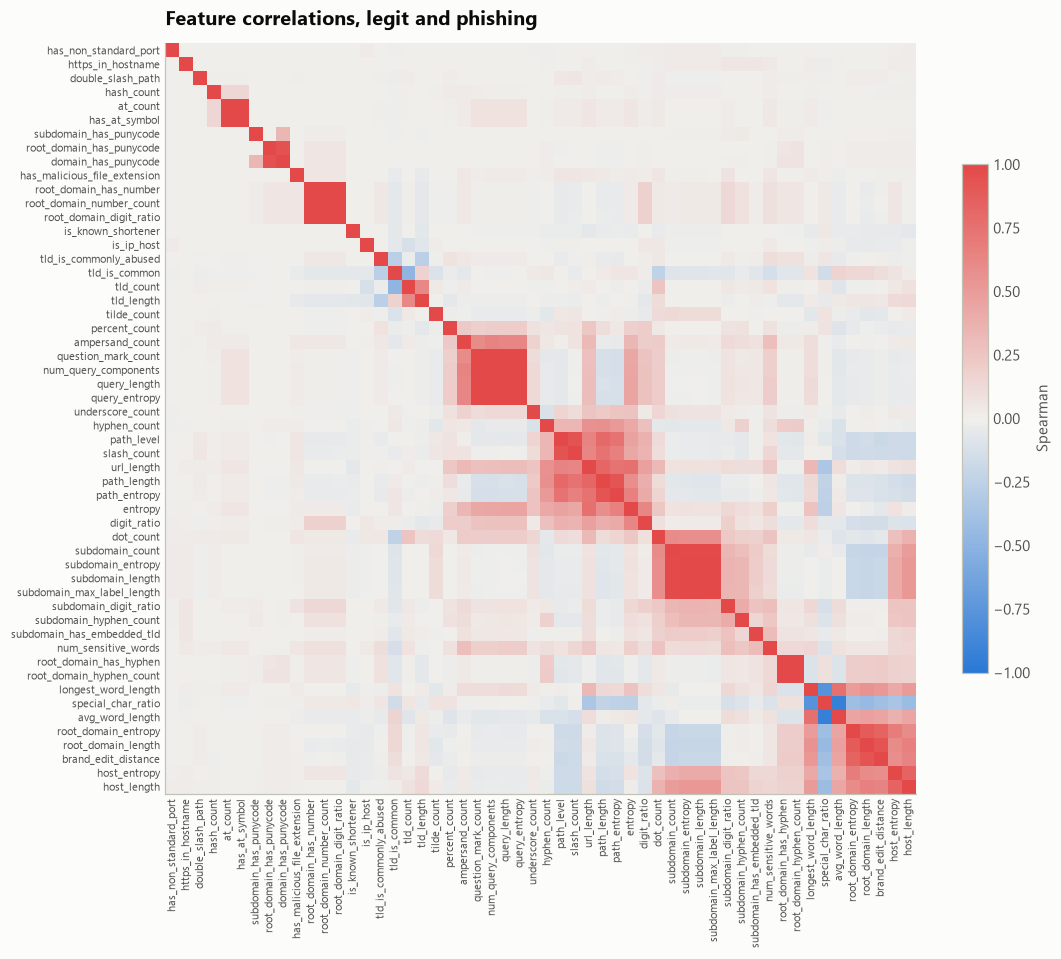

In [12]:
# Adapted from scikit-learn's "Permutation Importance with Multicollinear or Correlated Features" example:
# Spearman correlation -> distance (1 - |correlation|) -> hierarchical clustering -> heatmap in the clustering's order
#
spearman_corr = values.corr(method="spearman")

# === SEGMENT ===
# order features so correlated ones are neighbours
distance_matrix = 1 - spearman_corr.abs()  # invert correlation to get distance apart (biggest correlation = "smallest" together)
dist_linkage = linkage(squareform(distance_matrix), method="average") # cluster all similar features together in order
order = leaves_list(dist_linkage) # bottom to top, left to right order in the cluster tree
spearman_corr = spearman_corr.iloc[order, order] # reorder the correlation matrix based on the clustering order
# === SEGMENT ===

fig, ax = plt.subplots(figsize=(11, 10))
image = ax.imshow(spearman_corr, cmap=style.DIVERGING, vmin=-1, vmax=1) # constrain to -1 to 1 so the colour gradient actually shows
# between -1 and 1 and use our colour map, blue grey red 

ax.set_xticks(range(len(spearman_corr)), spearman_corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(spearman_corr)), spearman_corr.index, fontsize=7)
ax.grid(False)

fig.colorbar(image, ax=ax, shrink=0.6, label="Spearman")
ax.set_title("Feature correlations, legit and phishing")
style.save(fig, FIGURES / "features_correlation.png")
plt.show()

In [13]:
# Keep one feature from each group of near-duplicates. From the same scikit-learn example ("Selecting features from clusters")
# Cut at distance 0.1 = features whose |Spearman| correlation with each other is above 0.9 (pretty identical)
# Changed: the example keeps the first feature of each group, here it keeps the one with the strongest AUC from section 4
# because we want the strongest feature ideally
from collections import defaultdict

from scipy.cluster.hierarchy import fcluster

cluster_ids = fcluster(dist_linkage, 0.1, criterion="distance")
groups = defaultdict(list)
for feature, cluster_id in zip(values.columns, cluster_ids):  # values.columns is the original, unsorted order
    groups[cluster_id].append(feature)

keep = {cluster_id: max(group, key=signal.strength.get) for cluster_id, group in groups.items()}
print(f"{len(usable)} features -> {len(keep)} after keeping one per group")

pd.DataFrame([
    {"kept": keep[cluster_id], "dropped": ", ".join(f for f in group if f != keep[cluster_id])}
    for cluster_id, group in groups.items() if len(group)
])

54 features -> 39 after keeping one per group


,kept,dropped
0,path_level,slash_count
1,path_entropy,path_length
2,double_slash_path,
3,query_length,"num_query_components, query_entropy, question_..."
4,entropy,
5,host_entropy,
6,subdomain_length,"subdomain_count, subdomain_max_label_length, s..."
7,subdomain_digit_ratio,
8,subdomain_hyphen_count,
9,subdomain_has_punycode,


So some takeaways from this:

- There are several pairs of features that are highly correlated (|r| > 0.9), which may indicate collinearity.
- For example, `has_at_symbol` and `at_count` are highly correlated. All of the dark red (and blue) cells in the heatmap represent such highly correlated pairs.
- `avg_word_length` and `special_char_ratio` are strongly inversely correlated (-0.92). This passes the reality check: special characters are what split a URL into "words" (based on feature extraction logic), so more of them chops it into shorter words, and a URL made of long words has a lower share of special characters (its a ratio)
- Now, trees can deal with collinearity better than linear models, as they are less sensitive to multicollinearity since fundamentally they combine different features together. For a linear model, this can lead to bad interpretations due to instability if two features are highly correlated therefore in a linear model, only one feature per pair (or group) should be used. On the above heatmap, this would be basically gray, with a red line going diagonally top-left to bottom-right (since identical features are identically correlated)
- (Since our group is expecting that a linear model is inferior, we will keep this information in mind, and will strip out redundant features just for the linear model but keep them for the tree model we will train)

## 7. Can the two types be represented in 2D?

Well, we have a lot of features, about 54 dimensions. We cannot visualise this on a 2D plot directly. PCA squeezes all usable features (scaled) into the two directions that keep the most variation. If Legitimate and Phishing sit in separate clouds, a simple straight-line model could do well. If they overlap, the model needs to combine features in non-linear ways hinting at a tree model. Random sample of 10,000 legit and 10,000 phishing, view cut to the middle 98% so a few extreme URLs don't affect the PC axes

The largest variation = the largest principal component. The point of PCA is to reduce the dimensionality of the data while preserving as much variation (structure) as possible.

Standard deviations (z) is on the axes. Because everything has run through StandardScaler(), each feature has mean 0 and standard deviation 1, therefore at either axis at 0, the URL is just plain average.

explained variance ratio (first two components): [0.156 0.093]


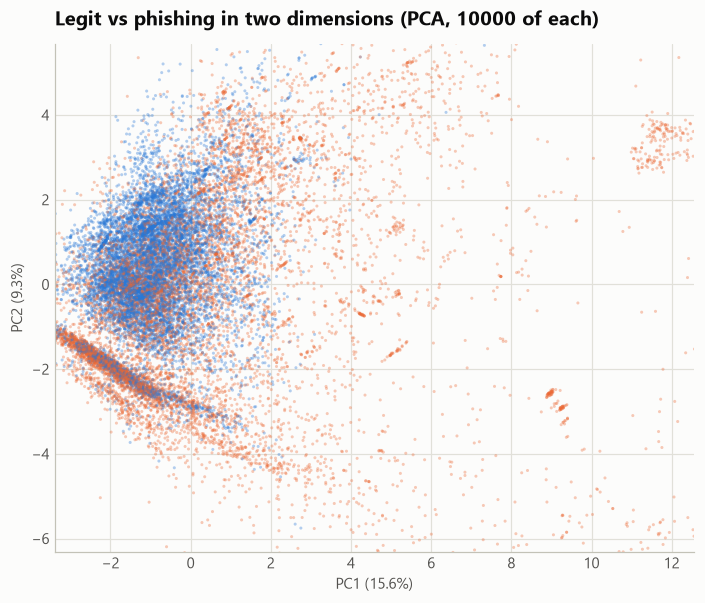

In [14]:
# Adapted from two scikit-learn examples (full references in references list):

SAMPLE = 10000
DOTSIZE = 4
TRANSPARENCY = 0.35


# 10,000 of each type
points_sample = legit_and_phishing.groupby("type", observed=True).sample(SAMPLE).sample(frac=1)
X = StandardScaler().fit_transform(points_sample[usable].astype(float))  # normalise every feature to mean 0, standard deviation 1
y = points_sample.type.to_numpy()

pca = PCA(n_components=2) # two component axes - the two strongest combination of features to get the most variance
X_r = pca.fit(X).transform(X)  # X_r = every URL as 2 numbers instead of 53 (same names as the example)

# Percentage of variance explained for each component (from the example)
print("explained variance ratio (first two components):", pca.explained_variance_ratio_.round(3))
explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(7.5, 6))
# the example draws one class after the other; here all points are shuffled,
# otherwise whichever class is drawn second would hide the first where they overlap (just a painting quirk)

ax.scatter(X_r[:, 0], X_r[:, 1], c=[style.TYPE_COLOURS[t] for t in y], s=DOTSIZE, alpha=TRANSPARENCY, linewidths=0)

ax.set_xlim(np.percentile(X_r[:, 0], [1, 99]))
ax.set_ylim(np.percentile(X_r[:, 1], [1, 99]))
ax.set_xlabel(f"PC1 ({explained[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}%)")
ax.set_title(f"Legit vs phishing in two dimensions (PCA, {SAMPLE} of each)")
ax.grid(True) # want grid for this one
style.save(fig, FIGURES / "features_pca.png")
plt.show()

#### What the PCA shows

- 2 dimensions only keeps about 25% of the variation, so this is just for visualisation, not the full story that a tree model will see
- **PC1** = how long and complicated the host is. **PC2** = long path/query vs long host
- **Legit is the big blob at the top left** Legit URLs look alike it seems comparing top8
- **Phishing is splattered everywhere.** But some is inside the legit blob, the rest spreads out into separate clumps (phishing URLs that look alike)
- Anything far from the legit blob is almost definitely a phishing URL

**So:**
- They overlap, so non-linear models (trees, random forest, KNN) will be better than logistic regressions
- Phishing has clear sub-groups, so upon clustering, the phishing URLs should have certain clusters

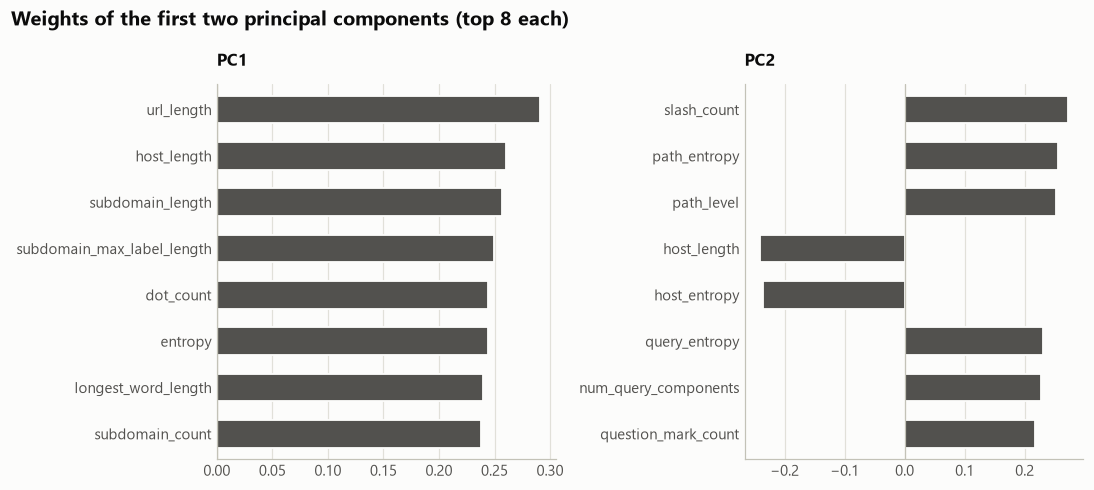

In [15]:
# What PC1 and PC2 are made of. Adapted from the "Importance of Feature Scaling" example's
# "Weights of the first principal component" bar chart, but only the 8 biggest weights per component instead of all 53
# A weight is how much one feature pushes a URL along that axis: big = matters a lot, the sign is just the direction on the axis
weights = pd.DataFrame(pca.components_.T, index=usable, columns=["PC1", "PC2"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, component in zip(axes, weights.columns):
    top_weights = weights[component].reindex(weights[component].abs().nlargest(8).index).iloc[::-1]  # biggest 8 weights at the top
    top_weights.plot.barh(ax=ax, color=style.INK_SOFT, width=0.6)
    ax.axvline(0, color=style.AXIS, linewidth=0.8)
    ax.set_title(f"{component}", fontsize=11)
    ax.grid(False, axis="y")
    ax.grid(True, axis="x")
fig.suptitle("Weights of the first two principal components (top 8 each)", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
style.save(fig, FIGURES / "features_pca_weights.png")
plt.show()

**Where this method comes from.** The PCA code is adapted from scikit-learn's *Comparison of LDA and PCA 2D projection of Iris dataset* example fit and transformed to 2 principal components, scatterplot coloured by type. The weights chart is adapted from its *Importance of Feature Scaling* example, which also shows why the features are standardised first: without it, a feature with big numbers (like `query_length`, up to 2,005) "dominates the direction of the principal components".

**What I changed from the example:**
- Balanced 10,000 / 10,000 sample (no class imbalance)
- One shuffled scatter instead of one class after the other, so neither class hides the other where they overlap (rendering because of the sheer amount of points)
- Small transparent dots for the 20,000 points, and the view cut to the middle 98% so a few extreme URLs don't extend the plot.
- Only the top 8 weighted features per axes instead of all features

## 8. Findings and decisions

| Section | What it showed | Decision |
|---------|----------------|-------------------|
| 1. Class balance | 83.3% legit vs 16.7% phishing. Always guessing "legit" already scores 83.3% accuracy | Don't judge models on accuracy. Use precision, recall, F1 and PR-AUC. |
| 2. Cleaning before/after | Scheme, www, quotes and `&amp;` are all (basically) 0% after cleaning. Phishing is now slightly longer than legit (45 vs 42), which matches reality | Cleaning worked. Keep the length features as normal features |
| 3. TLDs | `.com` is 72% of legit vs 52% of phishing, `.edu` is almost only legit. Malware's `.jp` (24.6%) is basically one site | TLD features are fine for legit vs phishing. Don't trust TLD patterns in malware/defacement, they come from how the list was collected, only used for testing anyways |
| 4. AUC | Strongest feature is host_length (0.67). Nothing near 0.8, so no shortcuts. 14 features pass the 0.2 correlation test. No feature is constant (`root_domain_has_punycode` was, before the extractor fix) | Keep the weaker features too, because certain model types can combine them |
| 5. Distributions | Counts and lengths are very skewed (query_length skew 10.5, 2.3 after log1p). The 1.5 x IQR rule flags up to 15% of URLs, but they're real URLs, not errors | Keep the outliers. Use log1p + StandardScaler for logistic regression, KNN and K-means. Trees use the raw values |
| 6. Correlations | Groups of near-duplicate features (query_*, subdomain_*, at_count / has_at_symbol...) | Keep one per group (54 → 39 features) for logistic regression, KNN and K-means. Trees keep all 54 features |
| 7. PCA | Legit is one tight blob. Phishing overlaps it and spreads into clumps. 2 dimensions keep only 25% variance (13.2 out of a total spread of 54, one unit per standardised feature) 75% of the data cannot be plotted on a flat two dimension scatter | Non-linear models should beat logistic regression. Clustering is effective on the phishing URLs. We can split by URL host to avoid clumps |

### Conclusion

- Tree models are best for such a data spread that looks like this
- Linear models won't do as well but still worth evaluating
- Cleaning worked
- Feature extraction was good with reasonable signals obtained

## References

**Unit material**
- Swinburne University of Technology (2026) *COS30049 Computing Technology Innovation Project*, Week 4 lecture and seminar, Week 6 lecture and seminar

**Code examples**
- Matplotlib (n.d.) *Bar chart with labels*. Available at: https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html.
- Matplotlib (n.d.) *Grouped bar chart with labels*. Available at: https://matplotlib.org/stable/gallery/lines_bars_and_markers/barchart.html.
- Matplotlib (n.d.) *Demo of the histogram function's different histtype settings*. Available at: https://matplotlib.org/stable/gallery/statistics/histogram_histtypes.html.
- Matplotlib (n.d.) *Horizontal bar chart*. Available at: https://matplotlib.org/stable/gallery/lines_bars_and_markers/barh.html.
- Matplotlib (n.d.) *Box plots with custom fill colors*. Available at: https://matplotlib.org/stable/gallery/statistics/boxplot_color.html.
- Matplotlib (n.d.) *matplotlib.axes.Axes.boxplot*. Available at: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.boxplot.html.
- Matplotlib (n.d.) *Annotated heatmap*. Available at: https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html.
- Matplotlib (n.d.) *Customizing Matplotlib with style sheets and rcParams*. Available at: https://matplotlib.org/stable/users/explain/customizing.html.
- NumPy (n.d.) *numpy.log1p*. Available at: https://numpy.org/doc/stable/reference/generated/numpy.log1p.html.
- pandas (n.d.) *10 minutes to pandas*. Available at: https://pandas.pydata.org/docs/user_guide/10min.html.
- pandas (n.d.) *pandas.crosstab*. Available at: https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html.
- pandas (n.d.) *pandas.DataFrame.corrwith*. Available at: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corrwith.html.
- scikit-learn (n.d.) *roc_auc_score*. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html.
- scikit-learn (n.d.) *FunctionTransformer*. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.FunctionTransformer.html.
- scikit-learn (n.d.) *Permutation Importance with Multicollinear or Correlated Features*. Available at: https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html.
- scikit-learn (n.d.) *Comparison of LDA and PCA 2D projection of Iris dataset*. Available at: https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_vs_lda.html.
- scikit-learn (n.d.) *Importance of Feature Scaling*. Available at: https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html.